# COCO Dataset Overview

### COCO 2017 dataset

The COCO (Common Objects in Context) dataset is a large-scale image recognition dataset used for various computer vision tasks like object detection, segmentation, and captioning. It contains over 330,000 images, each annotated with 80 object categories and 5 captions describing the scene.

COCO is benchmark dataset commonly used in machine learning—both for research and practical applications.

Overview of COCO 2017 dataset is given in [this blogpost](https://www.v7labs.com/blog/coco-dataset-guide) and in [paper 'Microsoft COCO: Common Objects in Context'](https://arxiv.org/abs/1405.0312).

### Display Images from Train Dataset with Captions

A single image has numerous different options for caption. In miniCOCO dataset 5 captions are assigned to each image manually.

We will pick a one image and display it with its captions.

In [21]:
import json
import matplotlib.pyplot as plt
import skimage.io as io
import os
from config import train_data_path, train_annFile

In [28]:
def get_ith_image(data_path, i):
    supported_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff')
    image_files = [f for f in os.listdir(data_path)
                   if f.lower().endswith(supported_extensions)]
    image_files.sort()

    if i < 0 or i >= len(image_files):
        raise IndexError(f"Index {i} is out of bounds for {len(image_files)} image(s).")

    img_path = os.path.join(data_path, image_files[i])
    img = io.imread(img_path)
    return {
        'img_name': image_files[i],
        'img': img
    }

In [29]:
img0_name, img0 = get_ith_image(train_data_path, 0)['img_name'], get_ith_image(train_data_path, 0)['img']
type(img0), img0.shape  # I is (w, h, 3) NumPy ndarray


(numpy.ndarray, (480, 640, 3))

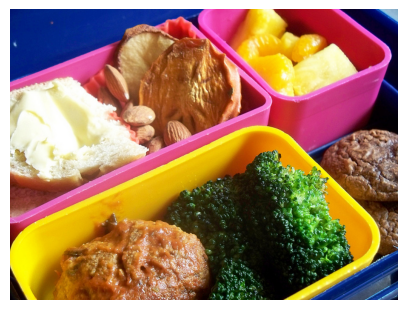

In [30]:
# Display the image
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.imshow(img0)
plt.show()

In [24]:
def get_captions(annFile, img_name):
    '''
    Collect captions for a given image name from the COCO 2017 annotation JSON file.
    '''
    with open(annFile, 'r') as f:
        coco_data = json.load(f)

    # find the image ID
    for image_info in coco_data.get('images', []):
        if image_info.get('file_name') == img_name:
            image_id = image_info['id']
            break
    if image_id is None:
        print(f'{img_name} not found in {train_annFile}')

    # collect image captions
    captions = []
    for annotation in coco_data.get('annotations', []):
        if annotation.get('image_id') == image_id:
            captions.append(annotation.get('caption'))

    return captions

In [31]:
get_captions(annFile=train_annFile,
             img_name=img0_name)

['Closeup of bins of food that include broccoli and bread.',
 'A meal is presented in brightly colored plastic trays.',
 'there are containers filled with different kinds of foods',
 'Colorful dishes holding meat, vegetables, fruit, and bread.',
 'A bunch of trays that have different food.']

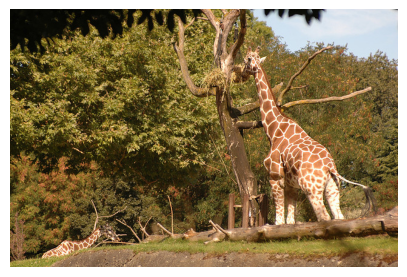

['A giraffe eating food from the top of the tree.',
 'A giraffe standing up nearby a tree ',
 'A giraffe mother with its baby in the forest.',
 'Two giraffes standing in a tree filled area.',
 'A giraffe standing next to a forest filled with trees.']

In [32]:
img1_name, img1 = get_ith_image(train_data_path, 1)['img_name'], get_ith_image(train_data_path, 1)['img']

# Display the image
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.imshow(img1)
plt.show()

# Print captions
get_captions(annFile=train_annFile,
             img_name=img1_name)

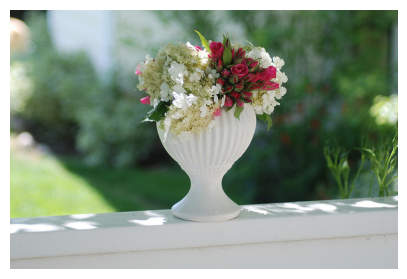

['A flower vase is sitting on a porch stand.',
 'White vase with different colored flowers sitting inside of it. ',
 'a white vase with many flowers on a stage',
 'A white vase filled with different colored flowers.',
 'A vase with red and white flowers outside on a sunny day.']

In [33]:
img2_name, img2 = get_ith_image(train_data_path, 2)['img_name'], get_ith_image(train_data_path, 2)['img']

# Display the image
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.imshow(img2)
plt.show()

# Print captions
get_captions(annFile=train_annFile,
             img_name=img2_name)

### Shapes of images

In [34]:
img0.shape

(480, 640, 3)

In [35]:
img1.shape

(426, 640, 3)

In [37]:
img2.shape

(428, 640, 3)

All images in miniCOCO dataset have 3 dimensions: height, width and number of color channels.

image shape = (h, w, 3)

The sizes of height and width differs, but the size of color channels is always 3, representing color image (RGB).